In [ ]:
'''
1.explain the main idea of evolutionary computation

EC - evloutionary computation is a family of optimization and search methods. Starts with a population of candidate solutions , improves them over multiple generartions.

'''

In [ ]:
# Population: many candidate solutions exist at the same time
# Fitness / objective function: each solution is evaluated
# Selection: better solutions are more likely to be chosen
# Variation: new solutions are created by mutation and recombination
# Replacement: a new generation is formed
# Termination: the process stops after a number of generations or when a good solution is found

In [ ]:
# Initialize a random population
# Evaluate all individuals
# Select parents
# Apply variation operators
# Build a new population
# Repeat 

In [ ]:
# A very high-level pseudocode for an evolutionary algorithm
'''
population = initialize_population()

for generation in range(max_generations):
    fitness_values = evaluate(population)
    parents = select(population, fitness_values)
    offspring = recombine_and_mutate(parents)
    population = replace(population, offspring)

best_solution = get_best(population)
print("Best solution found:", best_solution)
'''

In [ ]:
#individual = single candidate solution
#chromosome / genome = encoded form of a solution
#gene = component of the chromosome
#population = set of individuals
#fitness/ obj fct = numerical score showing how good a solution is
#mutation = small random change in one individual 
#crossover / recombination = combining information from two or more parents 
#selection = choose a better individual 

In [ ]:
'''
2.describe how a population of candidate solutions evolves

A population of candidate solutions evolves through mutation and recombination.
'''

In [1]:
#Represetation of solutions :

#binary 
#real-valued
#integer
#permutation
#tree represnetation for mathematical expresiions

#representation must match the problem

In [2]:
#Binary representation :

#solution encoded as a string of bits 0/1
#choose wheter 5 items are included in a solution : 1,0,1,1,0
#USED: subset selection/ feature selection / knapsack-type problems / yes/no decision problems

#sum function to count how many 1s in the chromosome 

In [3]:

# Binary representation example
x = [1, 0, 1, 1, 0]

# Objective: maximize the number of 1s
f = sum(x)
print("Binary solution:", x)
print("Objective value:", f)


Binary solution: [1, 0, 1, 1, 0]
Objective value: 3


In [ ]:
#Real valued representation:

#solution represented using real numbers 
#2.5,-1.2,0.75
#USED: continous optimization/ paramtere turning/ engineering design/ machine learning hyperparameters 

#minimization : x1^2+x2^2+x3^2-> goal of finding values close to zero 

In [4]:
# Real-valued representation example
x = [2.5, -1.2, 0.75]

f = sum(value**2 for value in x)
print("Real-valued solution:", x)
print("Objective value:", f)

Real-valued solution: [2.5, -1.2, 0.75]
Objective value: 8.2525


In [ ]:
#Integer representation:

#solution represented as integers
#3,1,4,2
#USED: schedualing, allocation, resource assignment, discrete parameter optimization
#if we want to minimiza the distance from a target vector z,z,z,z => sum (x-z)^2


In [5]:
# Integer representation example
x = [3, 1, 4, 2]

f = sum((value - 2)**2 for value in x)
print("Integer solution:", x)
print("Objective value:", f)

Integer solution: [3, 1, 4, 2]
Objective value: 6


In [ ]:
#Permutation representation :

#solution is ordered arrangement of elements
#3,1,4,2,5
#USED: traveling salesperson problem , job sequencing, ordering tasks, routing 
#minimize the total distance : d(x1,x2)+d(x2,x3)+...

#Important note: in permutation problems, standard bit-flip mutation or ordinary crossover may create invalid permutations, so specialized operators are needed

In [6]:
# Permutation representation example
# Suppose we have a very small distance matrix for 4 cities

distance = [
    [0, 2, 9, 10],
    [1, 0, 6, 4],
    [15, 7, 0, 8],
    [6, 3, 12, 0]
]

route = [0, 2, 3, 1]  # a permutation of the cities

def route_length(route, distance):
    total = 0
    for i in range(len(route) - 1):
        total += distance[route[i]][route[i + 1]]
    total += distance[route[-1]][route[0]]  # return to start
    return total

print("Permutation solution:", route)
print("Route length:", route_length(route, distance))

Permutation solution: [0, 2, 3, 1]
Route length: 21


In [8]:
#Tree representation for a mathematical expression

#Genetic programming - GP - solution can be represented as a tree
#x+2 X x-3
#root: multiplication
#left subtree x+2
#right subtree : x-3

#USED : synmbolic regression, automatic program generation , rule discovery , expression optimization 
#aproximates known points  minimize the mean squared error : 1/m sum(T(x)-y)^2


In [9]:

# Tree-like expression example (simulated in Python with a function)

def tree_expression(x):
    return (x + 2) * (x - 3)

data = [(-1, 0), (0, -6), (1, -6), (2, -4)]
mse = sum((tree_expression(x) - y)**2 for x, y in data) / len(data)

print("Mean squared error of the expression tree:", mse)

Mean squared error of the expression tree: 4.0


In [ ]:
'''
3.recognize different ways to represent solutions

solution for subset selection -> binary
solution for coninuous optimization : real valued 
solution for scheduling : integer
solution for routing, sequqncing : permutation
solution for symbolic regression : tree
'''

In [10]:
#Evolutionary algoritm :

#genetic algorithms 
# -> GA 
# -> binary strings/ discret encodings / crossover as a major operator
# -> components : binary or integer representation / tournament or roulette-wheel selection / one point or two point crossover / mutation with small probability

#evolution strategies  - for continuous optimization
# -> ES
# -> real valued / contnous parameters / mutation as a major operator 
# -> components : real valued representaton / gaussian mutation / survivor selection 



In [ ]:
'''
4.define an objective function for a given problem
5.distinguish between two important types of evolutionary
algorithms
6.design a simple binary-encoded evolutionary algorithm
'''

In [ ]:
'''
KNAPSACK - BINARY
items with value and weight
-> maximize total value + not exceed the maximum capacity

REPRESENTATION : binary -> [x1,x2,x3,...,xn]
xi=1 - selected / 0 - not selected

OBJECTIVE FUNCTION : vi - value , wi - weight , W - capacity 
value(x)=sum(vi*xi)
weight(x)=sum(wi*xi)
weight(x)<=W

PRACTICAL HANDLING OF INFEASIBLE SOLUTIONS 
use penalty : f(x)= sum (vi*xi) if sum(wi*xi)<=W, 0 otherwise

VARIATION OPERATORS FOR BINARY 
-> mutation : binary chromosome - bit flip ->[1,0,1,1,0]->[1,0,0,1,0]
-> selection : tournament selection or roulette wheel selection (tournament selection randomly choose a few individuals , keep best , repeat until enough parents are selected)
-> combination (crossover) : one/two point crossover , uniform crossover 
example one point : p1=[1,1,0,0,1], p2=[0,0,1,1,0] ->c1=[1,1,1,1,0] c2=[0,0,0,0,1] (cut after second position)

GUIDE TO BUILD THE WHOLE PROGRAM
1. define problem data -> list of values, list of weights , capacity
2. generate an initial population -> create many random binary vectors
3. evaluate the population -> compute fitnes for every chromosome
4. select parents -> use tournament 
5. create offspring -> apply crossover , apply mutation
6. build the next generation -> replace the old population with the offspring, or keep the best individual elitism
7. repeat -> run for a fixed number of generations 
8. return best solution - best chromosome , total value and total weight 

'''

In [11]:
# Problem data for the final exercise

values = [10, 6, 8, 4, 12, 7]
weights = [4, 2, 3, 1, 6, 2]
capacity = 10

n_items = len(values)

print("Values :", values)
print("Weights:", weights)
print("Capacity:", capacity)

Values : [10, 6, 8, 4, 12, 7]
Weights: [4, 2, 3, 1, 6, 2]
Capacity: 10


In [12]:
import random

def random_individual(n):
    return [random.randint(0, 1) for _ in range(n)]

def compute_weight(individual, weights):
    return sum(bit * w for bit, w in zip(individual, weights))

def compute_value(individual, values):
    return sum(bit * v for bit, v in zip(individual, values))

def fitness(individual, values, weights, capacity):
    total_weight = compute_weight(individual, weights)
    total_value = compute_value(individual, values)
    if total_weight <= capacity:
        return total_value
    return 0  # penalty for infeasible solutions

# Example
ind = random_individual(n_items)
print("Individual:", ind)
print("Weight:", compute_weight(ind, weights))
print("Value:", compute_value(ind, values))
print("Fitness:", fitness(ind, values, weights, capacity))


Individual: [1, 0, 1, 1, 0, 0]
Weight: 8
Value: 22
Fitness: 22


In [14]:

def tournament_selection(population, fitnesses, k=3):
    selected_indices = random.sample(range(len(population)), k)
    best_index = max(selected_indices, key=lambda i: fitnesses[i])
    return population[best_index][:]  # return a copy

def one_point_crossover(parent1, parent2):
    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def bit_flip_mutation(individual, mutation_rate=0.05):
    mutated = individual[:]
    for i in range(len(mutated)):
        if random.random() < mutation_rate:
            mutated[i] = 1 - mutated[i]
    return mutated

# Operator demo
p1 = random_individual(n_items)
p2 = random_individual(n_items)
c1, c2 = one_point_crossover(p1, p2)
m1 = bit_flip_mutation(c1, mutation_rate=0.2)

print("Parent 1:", p1)
print("Parent 2:", p2)
print("Child 1 :", c1)
print("Child 2 :", c2)
print("Mutated :", m1)


Parent 1: [0, 0, 1, 1, 0, 1]
Parent 2: [0, 0, 0, 1, 0, 1]
Child 1 : [0, 0, 0, 1, 0, 1]
Child 2 : [0, 0, 1, 1, 0, 1]
Mutated : [0, 0, 0, 1, 0, 0]


In [15]:

def genetic_algorithm_knapsack(values, weights, capacity,
                               population_size=20,
                               generations=30,
                               crossover_rate=0.8,
                               mutation_rate=0.05,
                               tournament_k=3):

    n = len(values)

    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1

    for generation in range(generations):
        fitnesses = [fitness(ind, values, weights, capacity) for ind in population]

        # Update global best
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]

        new_population = []

        new_population.append(generation_best[:])

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = one_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

        print(f"Generation {generation + 1:2d}: best fitness = {best_fitness}")

    return best_solution, best_fitness


In [ ]:
# where the population is initialized
# -> line 11
# where fitness is computed
# -> line 17
# where selection happens
# -> line 35
# where crossover happens
# -> line 38
# where mutation happens
# -> line 43
# how the next generation is formed
# -> using Elitism , keeping the best individual

In [16]:

best_solution, best_fitness = genetic_algorithm_knapsack(
    values, weights, capacity,
    population_size=20,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.05,
    tournament_k=3
)

best_weight = compute_weight(best_solution, weights)
best_value = compute_value(best_solution, values)

print("\nBest solution found:", best_solution)
print("Total weight:", best_weight)
print("Total value :", best_value)
print("Fitness     :", best_fitness)


Generation  1: best fitness = 28
Generation  2: best fitness = 28
Generation  3: best fitness = 28
Generation  4: best fitness = 28
Generation  5: best fitness = 28
Generation  6: best fitness = 28
Generation  7: best fitness = 28
Generation  8: best fitness = 29
Generation  9: best fitness = 29
Generation 10: best fitness = 29
Generation 11: best fitness = 29
Generation 12: best fitness = 29
Generation 13: best fitness = 29
Generation 14: best fitness = 29
Generation 15: best fitness = 29
Generation 16: best fitness = 29
Generation 17: best fitness = 29
Generation 18: best fitness = 29
Generation 19: best fitness = 29
Generation 20: best fitness = 29
Generation 21: best fitness = 29
Generation 22: best fitness = 29
Generation 23: best fitness = 29
Generation 24: best fitness = 29
Generation 25: best fitness = 29
Generation 26: best fitness = 29
Generation 27: best fitness = 29
Generation 28: best fitness = 29
Generation 29: best fitness = 29
Generation 30: best fitness = 29

Best solu

In [45]:
def two_point_crossover(p1, p2):
    n = len(p1)
    i, j = sorted(random.sample(range(n), 2))
    
    child1 = p1[:i] + p2[i:j] + p1[j:]
    child2 = p2[:i] + p1[i:j] + p2[j:]
    
    return child1, child2

In [52]:
def new_fitness(ind, values, weights, capacity):
    total_value = sum(v for v, x in zip(values, ind) if x)
    total_weight = sum(w for w, x in zip(weights, ind) if x)

    if total_weight > capacity:
        return total_value - 2 * (total_weight - capacity)  # penalty

    return total_value

In [57]:


def genetic_algorithm_knapsack_with_history(values, weights, capacity,
                                            population_size=20,
                                            generations=30,
                                            crossover_rate=0.8,
                                            mutation_rate=0.05,
                                            tournament_k=3):
    n = len(values)
    population = [random_individual(n) for _ in range(population_size)]

    best_solution = None
    best_fitness = -1
    history = []

    no_improve_count=0
    max_no_imrpove=10
    
    for generation in range(generations):
        fitnesses = [new_fitness(ind, values, weights, capacity) for ind in population]
        generation_best_index = max(range(population_size), key=lambda i: fitnesses[i])
        generation_best = population[generation_best_index]
        generation_best_fitness = fitnesses[generation_best_index]

        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_solution = generation_best[:]
            no_improve_count = 0
        else:
            no_improve_count += 1
        
        if no_improve_count > max_no_imrpove:
            print("Stopped early due to no improvement")
            break
        history.append(best_fitness)

        new_population = [generation_best[:]]
        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitnesses, k=tournament_k)
            parent2 = tournament_selection(population, fitnesses, k=tournament_k)

            if random.random() < crossover_rate:
                child1, child2 = two_point_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]

            child1 = bit_flip_mutation(child1, mutation_rate)
            child2 = bit_flip_mutation(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_solution, best_fitness, history


Stopped early due to no improvement


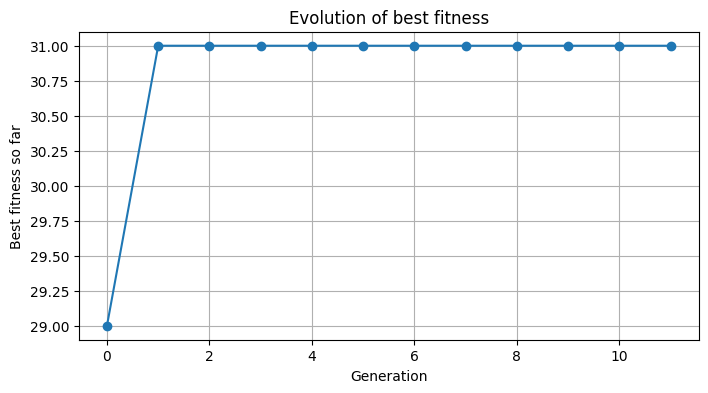

In [58]:

# Optional plot
import matplotlib.pyplot as plt

best_solution, best_fitness, history = genetic_algorithm_knapsack_with_history(
    values, weights, capacity,
    population_size=20,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.05,
    tournament_k=3
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best fitness so far")
plt.title("Evolution of best fitness")
plt.grid(True)
plt.show()


In [ ]:
# Change the mutation rate and observe the effect. -> if it is too low 0.001 it may get stuck, if it's to high becomes random like and destroies good solutions
# Change the population size. -> to small , miss good solutions , too large , slower 
# Try two-point crossover instead of one-point crossover. -> it mixes the gesnes more 
# Replace the penalty value 0 with a stronger penalty formula. -> we penalize based on how bad it is -> went from 25-29 to 29-31
# Add a stopping rule based on no improvement. -> doesn't waste time anymore 